# Damped oscillator: energy decay rate
**Author:** (your name) · **Date:** (date)  
**Purpose:** estimate the damping rate $\gamma$ from the energy of a simulated damped oscillator and check that it recovers the value we set.

## 1. Imports (all of them, here only)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

## 2. Settings
Physical parameters and numerical tolerances. $\omega = 2\pi$ rad/s (period 1 s), $\gamma = 0.1\ \mathrm{s^{-1}}$.

In [2]:
OMEGA, GAMMA = 2 * np.pi, 0.1
RTOL, ATOL = 1e-9, 1e-11
T_END, N_T = 20.0, 4000

## 3. Data
Simulate $\ddot x = -2\gamma\dot x - \omega^2 x$ and check that the solver succeeded.

In [3]:
def ho_rhs(time, y, omega, gamma):
    x, v = y
    return [v, -2 * gamma * v - omega**2 * x]

time_s = np.linspace(0, T_END, N_T)          # time [s]  (not 't')
sol = solve_ivp(ho_rhs, (0, T_END), [1.0, 0.0], t_eval=time_s,
                args=(OMEGA, GAMMA), rtol=RTOL, atol=ATOL)
assert sol.success
x, v = sol.y
print(f'{time_s.size} points, x(0) = {x[0]}, v(0) = {v[0]}')

4000 points, x(0) = 1.0, v(0) = 0.0


## 4. Analysis
Energy per unit mass, then a fit of $E(t) = A e^{-2\gamma t}$.

gamma set = 0.1, gamma fit = 0.1001


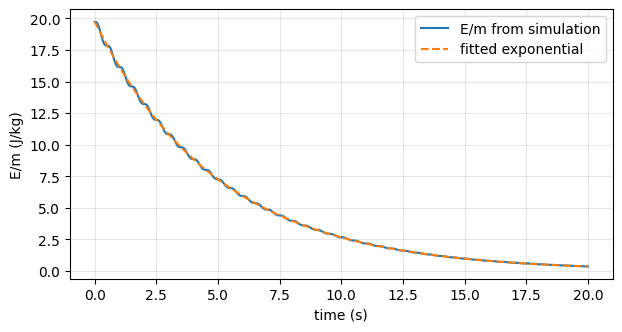

In [4]:
E = 0.5 * v**2 + 0.5 * OMEGA**2 * x**2
popt, _ = curve_fit(lambda tt, A, k: A * np.exp(-k * tt), time_s, E, p0=[E[0], 0.2])
gamma_fit = popt[1] / 2
print(f'gamma set = {GAMMA}, gamma fit = {gamma_fit:.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(time_s, E, label='E/m from simulation')
ax.plot(time_s, popt[0] * np.exp(-popt[1] * time_s), '--', label='fitted exponential')
ax.set_xlabel('time (s)'); ax.set_ylabel('E/m (J/kg)'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 5. Conclusion
The fitted $\gamma$ agrees with the value set to three decimals, so the simulation and the fit are consistent. **Limitation:** $e^{-2\gamma t}$ is only the average trend; it is accurate because $\gamma \ll \omega$ here (see E2.4). **Next step:** repeat for larger $\gamma$.